## House Prices: Understanding & Comparing Gradient Boosting & Encoding Techniques

**Goal:** Predict house prices with XGBoost.

**Plan:**
1. Log-transform SalePrice since it is skewed.
2. Fill NA where it means the feature is missing, not the data.
3. Fill LotFrontage with the neighborhood median.
4. Convert MSSubClass to text since it is a category.
5. Ordinal encode quality ratings, one-hot encode the rest.
6. Train XGBoost, check the score, predict test prices.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


## 1. Data Ingestion & Initial Inspection

We load both `train.csv` (containing `SalePrice`) and `test.csv` (which lacks `SalePrice` and requires our predictions).


In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(f"Training dataset shape:   {train.shape}")
print(f"Test dataset shape:       {test.shape}")
train.head()


Training dataset shape:   (1460, 81)
Test dataset shape:       (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Look at the target

SalePrice is right-skewed  most houses are average-priced, a few are very expensive. We log-transform it with log1p before training so big errors on expensive houses don't dominate. We turn predictions back into dollars with expm1 at the end.


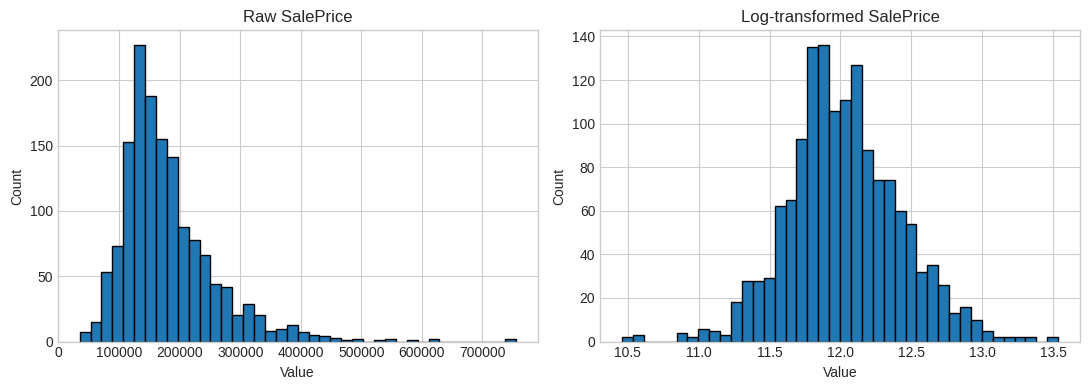

In [5]:
TARGET_COLUMN = 'SalePrice'
target = train[TARGET_COLUMN]
target_log = np.log1p(target)

datasets = [
    ('Raw SalePrice', target),
    ('Log-transformed SalePrice', target_log),
]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(11, 4))

for ax, (label, data) in zip(axes, datasets):
    ax.hist(data, bins=40, edgecolor='black')
    ax.set_title(label)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Missing values

Checking **data_description.txt**, many NA values here don't mean data is missing, they mean the house doesn't have that feature:
- PoolQC = NA means no pool
- GarageType = NA means no garage
- BsmtQual = NA means no basement

So we handle them in groups:
1. Categoricals where NA means none, fill with None
2. Numerics where NA means 0, such as garage area and basement area
3. LotFrontage, fill with the median of the same neighborhood
4. The few genuinely missing values, fill with the most common value (mode)


In [6]:
n_train = train.shape[0]
y = np.log1p(train['SalePrice'])
all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0, ignore_index=True)


none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in none_cols:
    all_data[col] = all_data[col].fillna('None')


zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath'
]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)


all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda s: s.fillna(s.median())
)

mode_cols = [
    'MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
    'Electrical', 'KitchenQual', 'Functional', 'SaleType'
]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print(f"Remaining unhandled missing values across all_data: {all_data.isnull().sum().sum()}")


Remaining unhandled missing values across all_data: 0


## 4. Correcting Numerical Encodings: `MSSubClass`

`MSSubClass` records building types using numbers (`20`, `60`, `120`, etc.). These are **discrete categorical codes**, not physical measurements. 

Leaving them as integers would lead linear models and tree-split algorithms to assume an artificial numerical order (e.g. that class 120 is double class 60). Converting them to string ensures they are properly handled as nominal categories.


In [27]:
all_data['MSSubClass'] = all_data['MSSubClass'].astype(str)


## 5. Preserve a Clean Categorical Version for Encoding Experiments

Before we apply ordinal mappings, we save a copy of the cleaned data.

This is important because the next part of the project compares different encoding techniques. Some encoders need the original category names such as `RL`, `RM`, `CollgCr`, or `Gd`.

We therefore keep two ideas separate:

- `encoding_base`: cleaned categorical data before encoding
- `all_data`: the working version used by the original baseline pipeline

This allows us to compare encoding methods without destroying the original information.

In [7]:
encoding_base = all_data.copy()

categorical_columns = encoding_base.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns available for encoding: {len(categorical_columns)}")
print(categorical_columns)

Categorical columns available for encoding: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## 6. Ordinal encode the quality columns

Some columns use a quality rating from None up to Ex. Since there is a clear order, I map them to numbers from 0 to 5 instead of one-hot encoding them. That way the model knows Ex is better than Fa.


In [8]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
quality_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

for col in quality_cols:
    all_data[col] = all_data[col].map(quality_map)

all_data['BsmtExposure'] = all_data['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4})
all_data['BsmtFinType1'] = all_data['BsmtFinType1'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
all_data['BsmtFinType2'] = all_data['BsmtFinType2'].map({'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6})
all_data['GarageFinish'] = all_data['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3})


## 7. One-Hot Encoding Nominal Features & Train/Test Partitioning

Features that lack natural hierarchy (e.g., `Neighborhood`, `MSZoning`, `SaleType`, `MSSubClass`) are converted into binary dummy variables via `pd.get_dummies(drop_first=True)`. 

Because this is performed on the unified `all_data`, training and test matrices share identical column schemas.


In [9]:
all_data = pd.get_dummies(all_data, drop_first=True)

X = all_data.iloc[:n_train, :].drop('Id', axis=1)
X_test = all_data.iloc[n_train:, :].drop('Id', axis=1)

print(f"X (training features) shape: {X.shape}")
print(f"X_test (test features) shape: {X_test.shape}")


X (training features) shape: (1460, 214)
X_test (test features) shape: (1459, 214)


### Baseline Note

The original pipeline above remains in the notebook intentionally.

It represents our **baseline model using the original preprocessing decisions**, including domain-specific ordinal mappings followed by one-hot encoding.

The ten-encoding experiment below is separate so that we can compare alternative categorical representations without destroying the original workflow.

## 8. Comparing Multiple Categorical Encoding Techniques

We now move beyond the original one-hot encoding.

A categorical variable contains labels rather than naturally measurable numbers. For example:

`Neighborhood = CollgCr, Veenker, Crawfor, NoRidge, ...`

A machine-learning model needs numerical input, so an encoder converts those categories into numbers.

There is no single encoding method that is always best. Different encoders make different assumptions and create different representations.

In this project we will study and test ten techniques:

1. One-Hot Encoding
2. Ordinal Encoding
3. Label Encoding
4. Frequency Encoding
5. Count Encoding
6. Binary Encoding
7. Target Mean Encoding
8. Hash Encoding
9. Base-N Encoding
10. Leave-One-Out Target Encoding

The important goal is not simply to get ten models. The goal is to understand what information each representation gives to the model and what risks it introduces.

### 8.1 Experimental Rules

To make the comparison meaningful, we keep the following conditions fixed:

- the same train/validation split
- the same target transformation: `log1p(SalePrice)`
- the same XGBoost model configuration
- the same random seed
- the same cleaned source data
- the same validation metric: RMSE on the log target

Only the categorical encoding strategy changes.

This means that differences in validation RMSE are primarily associated with the representation of the categorical variables.

In [10]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.base import clone
import hashlib

### 8.2 Helper Functions

The functions below convert categorical columns into numerical representations.

We deliberately build several encoders ourselves so that the transformation is visible rather than hidden inside a library.

In [11]:
def prepare_numeric_base(df, categorical_cols):
    numeric = df.drop(columns=categorical_cols, errors='ignore').copy()
    numeric = numeric.select_dtypes(exclude=['object']).copy()
    return numeric


def frequency_encode(train_df, val_df, test_df, columns):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    for col in columns:
        frequencies = train_df[col].value_counts(normalize=True)
        train_out[col + '_freq'] = train_df[col].map(frequencies).fillna(0)
        val_out[col + '_freq'] = val_df[col].map(frequencies).fillna(0)
        test_out[col + '_freq'] = test_df[col].map(frequencies).fillna(0)

    return train_out, val_out, test_out


def count_encode(train_df, val_df, test_df, columns):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    for col in columns:
        counts = train_df[col].value_counts()
        train_out[col + '_count'] = train_df[col].map(counts).fillna(0)
        val_out[col + '_count'] = val_df[col].map(counts).fillna(0)
        test_out[col + '_count'] = test_df[col].map(counts).fillna(0)

    return train_out, val_out, test_out


def label_encode(train_df, val_df, test_df, columns):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    for col in columns:
        categories = pd.Index(train_df[col].astype(str).unique())
        mapping = {value: i for i, value in enumerate(categories)}
        train_out[col + '_label'] = train_df[col].astype(str).map(mapping).fillna(-1)
        val_out[col + '_label'] = val_df[col].astype(str).map(mapping).fillna(-1)
        test_out[col + '_label'] = test_df[col].astype(str).map(mapping).fillna(-1)

    return train_out, val_out, test_out


def binary_digits(value, width):
    return [int(bit) for bit in format(int(value), f'0{width}b')]


def binary_encode(train_df, val_df, test_df, columns):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    for col in columns:
        categories = pd.Index(train_df[col].astype(str).unique())
        mapping = {value: i for i, value in enumerate(categories)}
        width = max(1, int(np.ceil(np.log2(max(2, len(mapping))))))

        train_codes = train_df[col].astype(str).map(mapping).fillna(0).astype(int)
        val_codes = val_df[col].astype(str).map(mapping).fillna(0).astype(int)
        test_codes = test_df[col].astype(str).map(mapping).fillna(0).astype(int)

        train_bits = np.array([binary_digits(x, width) for x in train_codes])
        val_bits = np.array([binary_digits(x, width) for x in val_codes])
        test_bits = np.array([binary_digits(x, width) for x in test_codes])

        for j in range(width):
            name = f'{col}_bin_{j}'
            train_out[name] = train_bits[:, j]
            val_out[name] = val_bits[:, j]
            test_out[name] = test_bits[:, j]

    return train_out, val_out, test_out


def base_n_digits(value, base, width):
    digits = []
    number = int(value)
    for _ in range(width):
        digits.append(number % base)
        number //= base
    return digits[::-1]


def base_n_encode(train_df, val_df, test_df, columns, base=3):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    for col in columns:
        categories = pd.Index(train_df[col].astype(str).unique())
        mapping = {value: i for i, value in enumerate(categories)}
        n_categories = max(1, len(mapping))
        width = max(1, int(np.ceil(np.log(max(2, n_categories) ) / np.log(base))))

        train_codes = train_df[col].astype(str).map(mapping).fillna(0).astype(int)
        val_codes = val_df[col].astype(str).map(mapping).fillna(0).astype(int)
        test_codes = test_df[col].astype(str).map(mapping).fillna(0).astype(int)

        train_digits = np.array([base_n_digits(x, base, width) for x in train_codes])
        val_digits = np.array([base_n_digits(x, base, width) for x in val_codes])
        test_digits = np.array([base_n_digits(x, base, width) for x in test_codes])

        for j in range(width):
            name = f'{col}_base{base}_{j}'
            train_out[name] = train_digits[:, j]
            val_out[name] = val_digits[:, j]
            test_out[name] = test_digits[:, j]

    return train_out, val_out, test_out


def hash_encode(train_df, val_df, test_df, columns, n_bins=8):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    for col in columns:
        for row_df, output_df in [
            (train_df, train_out),
            (val_df, val_out),
            (test_df, test_out)
        ]:
            hashed = row_df[col].astype(str).apply(
                lambda value: int(hashlib.md5(value.encode()).hexdigest(), 16) % n_bins
            )
            output_df[col + '_hash'] = hashed.values

    return train_out, val_out, test_out


def target_mean_encode(train_df, val_df, test_df, y_train, columns, smoothing=10):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    global_mean = y_train.mean()

    for col in columns:
        stats = pd.DataFrame({
            'category': train_df[col].astype(str).values,
            'target': y_train.values
        }).groupby('category')['target'].agg(['mean', 'count'])

        smoothed = (
            (stats['mean'] * stats['count'] + global_mean * smoothing) /
            (stats['count'] + smoothing)
        )

        train_out[col + '_target_mean'] = train_df[col].astype(str).map(smoothed).fillna(global_mean).values
        val_out[col + '_target_mean'] = val_df[col].astype(str).map(smoothed).fillna(global_mean).values
        test_out[col + '_target_mean'] = test_df[col].astype(str).map(smoothed).fillna(global_mean).values

    return train_out, val_out, test_out


def loo_target_encode(train_df, val_df, test_df, y_train, columns, smoothing=10):
    train_out = prepare_numeric_base(train_df, columns)
    val_out = prepare_numeric_base(val_df, columns)
    test_out = prepare_numeric_base(test_df, columns)

    global_mean = y_train.mean()

    for col in columns:
        temp = pd.DataFrame({
            'category': train_df[col].astype(str).values,
            'target': y_train.values
        })

        grouped = temp.groupby('category')['target'].agg(['sum', 'count'])

        train_sum = train_df[col].astype(str).map(grouped['sum']).values
        train_count = train_df[col].astype(str).map(grouped['count']).values

        loo_sum = train_sum - y_train.values
        loo_count = train_count - 1

        train_values = (
            loo_sum + global_mean * smoothing
        ) / (
            loo_count + smoothing
        )

        mapping = (
            (grouped['sum'] + global_mean * smoothing) /
            (grouped['count'] + smoothing)
        )

        val_values = val_df[col].astype(str).map(mapping).fillna(global_mean).values
        test_values = test_df[col].astype(str).map(mapping).fillna(global_mean).values

        train_out[col + '_loo_target'] = train_values
        val_out[col + '_loo_target'] = val_values
        test_out[col + '_loo_target'] = test_values

    return train_out, val_out, test_out

## 8.3 Create the Same Train/Validation/Test Partitions

The encoding comparison must not repeatedly create different validation sets.

We first split the cleaned categorical dataset once. Every encoding method receives exactly the same rows.

This also gives us a safe boundary for target-based encoders: target information from the validation set is never used to construct its encoding.

In [12]:
encoding_train, encoding_val = train_test_split(
    encoding_base.iloc[:n_train].copy(),
    test_size=0.20,
    random_state=42
)

encoding_test = encoding_base.iloc[n_train:].copy()

y_encoding_train = y.loc[encoding_train.index]
y_encoding_val = y.loc[encoding_val.index]

print(f"Encoding training rows:   {len(encoding_train)}")
print(f"Encoding validation rows: {len(encoding_val)}")
print(f"Encoding test rows:       {len(encoding_test)}")

Encoding training rows:   1168
Encoding validation rows: 292
Encoding test rows:       1459


## 8.4 Encoding 1: One-Hot Encoding

One-hot encoding creates a separate binary column for each category.

For example:

`Neighborhood = CollgCr`

becomes something similar to:

`Neighborhood_CollgCr = 1`

and the other neighborhood columns become `0`.

### Strength

It does not assume that one category is numerically greater than another.

### Weakness

A feature with many unique categories can produce many columns.

This is the original encoding approach in our notebook, so it is our baseline.

In [13]:
onehot_train = pd.get_dummies(
    encoding_train,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

onehot_val = pd.get_dummies(
    encoding_val,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

onehot_test = pd.get_dummies(
    encoding_test,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

onehot_val = onehot_val.reindex(columns=onehot_train.columns, fill_value=0)
onehot_test = onehot_test.reindex(columns=onehot_train.columns, fill_value=0)

X_train_onehot = onehot_train.drop(columns=['Id'])
X_val_onehot = onehot_val.drop(columns=['Id'])
X_test_onehot = onehot_test.drop(columns=['Id'])

print(X_train_onehot.shape)

(1168, 257)


## 8.5 Encoding 2: Ordinal Encoding

Ordinal encoding represents categories with ordered numerical values.

This is appropriate only when the categories have a meaningful order.

For example:

`ExterQual: None < Po < Fa < TA < Gd < Ex`

can be represented as:

`0 < 1 < 2 < 3 < 4 < 5`

For genuinely nominal variables such as neighborhood names, this ordering does not naturally exist.

We therefore apply ordinal encoding generically here as an experiment, while the earlier section of the notebook uses manually defined domain knowledge for the known quality scales.

In [14]:
ordinal_train = prepare_numeric_base(encoding_train, categorical_columns)
ordinal_val = prepare_numeric_base(encoding_val, categorical_columns)
ordinal_test = prepare_numeric_base(encoding_test, categorical_columns)

ordinal_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

ordinal_train_values = ordinal_encoder.fit_transform(encoding_train[categorical_columns])
ordinal_val_values = ordinal_encoder.transform(encoding_val[categorical_columns])
ordinal_test_values = ordinal_encoder.transform(encoding_test[categorical_columns])

for j, col in enumerate(categorical_columns):
    ordinal_train[col + '_ordinal'] = ordinal_train_values[:, j]
    ordinal_val[col + '_ordinal'] = ordinal_val_values[:, j]
    ordinal_test[col + '_ordinal'] = ordinal_test_values[:, j]

X_train_ordinal = ordinal_train.drop(columns=['Id'])
X_val_ordinal = ordinal_val.drop(columns=['Id'])
X_test_ordinal = ordinal_test.drop(columns=['Id'])

print(X_train_ordinal.shape)

(1168, 79)


## 8.6 Encoding 3: Label Encoding

Label encoding assigns an integer identifier to each category.

Example:

`RL → 0`

`RM → 1`

`FV → 2`

This is compact because one categorical column becomes one numerical column.

However, the numbers are identifiers, not real measurements. The model may therefore see an artificial numerical relationship.

We include it here because it is an important encoding technique to understand and compare.

In [15]:
X_train_label, X_val_label, X_test_label = label_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    categorical_columns
)

X_train_label = X_train_label.drop(columns=['Id'])
X_val_label = X_val_label.drop(columns=['Id'])
X_test_label = X_test_label.drop(columns=['Id'])

print(X_train_label.shape)

(1168, 79)


## 8.7 Encoding 4: Frequency Encoding

Frequency encoding replaces each category with the proportion of training rows belonging to that category.

For example, if 200 of 1,000 houses belong to `Neighborhood = NAmes`:

`NAmes → 0.20`

This captures how common a category is without creating one column per category.

The frequency mapping is learned from the training set and then applied to validation and test data.

In [16]:
X_train_frequency, X_val_frequency, X_test_frequency = frequency_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    categorical_columns
)

X_train_frequency = X_train_frequency.drop(columns=['Id'])
X_val_frequency = X_val_frequency.drop(columns=['Id'])
X_test_frequency = X_test_frequency.drop(columns=['Id'])

print(X_train_frequency.shape)

(1168, 79)


## 8.8 Encoding 5: Count Encoding

Count encoding is closely related to frequency encoding.

Instead of a proportion, it stores the number of training examples belonging to each category.

For example:

`NAmes → 200`

The distinction is:

- frequency encoding: `200 / 1000 = 0.20`
- count encoding: `200`

Both represent category prevalence, but on different scales.

In [17]:
X_train_count, X_val_count, X_test_count = count_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    categorical_columns
)

X_train_count = X_train_count.drop(columns=['Id'])
X_val_count = X_val_count.drop(columns=['Id'])
X_test_count = X_test_count.drop(columns=['Id'])

print(X_train_count.shape)

(1168, 79)


## 8.9 Encoding 6: Binary Encoding

Binary encoding first assigns an integer to each category and then represents that integer using binary digits.

For example:

`0 → 000`

`1 → 001`

`2 → 010`

`3 → 011`

This usually creates fewer columns than one-hot encoding when a feature contains many categories.

It also avoids producing one huge sparse column for every category.

In [31]:
X_train_binary, X_val_binary, X_test_binary = binary_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    categorical_columns
)

X_train_binary = X_train_binary.drop(columns=['Id'])
X_val_binary = X_val_binary.drop(columns=['Id'])
X_test_binary = X_test_binary.drop(columns=['Id'])

print(X_train_binary.shape)

(1168, 154)


/tmp/ipykernel_36920/92347365.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_out[name] = train_bits[:, j]
/tmp/ipykernel_36920/92347365.py:75: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  val_out[name] = val_bits[:, j]
/tmp/ipykernel_36920/92347365.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = fr

## 8.10 Encoding 7: Target Mean Encoding

Target mean encoding replaces a category with the average target associated with that category.

For this project, the target is log-transformed `SalePrice`.

For example, if houses in one neighborhood have an average log price of `12.1`, that neighborhood can be represented by approximately `12.1`.

This can be extremely informative because the encoding directly captures the relationship between a category and the prediction target.

But it introduces a major danger: **target leakage**.

We therefore calculate the category statistics using training data only and use smoothing so that categories with very few examples do not receive unstable averages.

In [32]:
X_train_target, X_val_target, X_test_target = target_mean_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    y_encoding_train,
    categorical_columns,
    smoothing=10
)

X_train_target = X_train_target.drop(columns=['Id'])
X_val_target = X_val_target.drop(columns=['Id'])
X_test_target = X_test_target.drop(columns=['Id'])

print(X_train_target.shape)

(1168, 79)


## 8.11 Encoding 8: Hash Encoding

Hash encoding sends category names through a hash function and maps them into a fixed number of bins.

The important property is that the number of generated columns is controlled in advance.

This can be useful when categorical variables have extremely high cardinality.

A trade-off is possible hash collision: two different categories may map to the same bin.

In [20]:
X_train_hash, X_val_hash, X_test_hash = hash_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    categorical_columns,
    n_bins=8
)

X_train_hash = X_train_hash.drop(columns=['Id'])
X_val_hash = X_val_hash.drop(columns=['Id'])
X_test_hash = X_test_hash.drop(columns=['Id'])

print(X_train_hash.shape)

(1168, 79)


## 8.12 Encoding 9: Base-N Encoding

Base-N encoding generalizes binary encoding.

Instead of representing an integer using only `0` and `1`, we represent it using digits from another base.

Here we use base 3.

The same category identifier can therefore be represented using ternary digits rather than binary digits.

The advantage is that the number of columns can be controlled by the selected base.

In [21]:
X_train_base3, X_val_base3, X_test_base3 = base_n_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    categorical_columns,
    base=3
)

X_train_base3 = X_train_base3.drop(columns=['Id'])
X_val_base3 = X_val_base3.drop(columns=['Id'])
X_test_base3 = X_test_base3.drop(columns=['Id'])

print(X_train_base3.shape)

(1168, 119)


## 8.13 Encoding 10: Leave-One-Out Target Encoding

Leave-One-Out target encoding is another target-based method.

For each training row, the row's own target value is excluded when calculating its category mean.

This reduces the direct self-leakage that can happen when a row contributes its own target to the category statistic used to encode itself.

Validation and test rows use statistics calculated from the complete training partition.

We also apply smoothing toward the global mean.

In [22]:
X_train_loo, X_val_loo, X_test_loo = loo_target_encode(
    encoding_train,
    encoding_val,
    encoding_test,
    y_encoding_train,
    categorical_columns,
    smoothing=10
)

X_train_loo = X_train_loo.drop(columns=['Id'])
X_val_loo = X_val_loo.drop(columns=['Id'])
X_test_loo = X_test_loo.drop(columns=['Id'])

print(X_train_loo.shape)

(1168, 79)


## 8.14 Check the Encoded Datasets

Before training models, we check the number of features created by every encoding technique.

This is important because encoding is not only about predictive performance.

We should also ask:

- How many columns did the encoder create?
- Did it create missing values?
- Did it accidentally keep text columns?
- Does it use target information?
- Does it increase dimensionality dramatically?

In [23]:
encoding_datasets = {
    'One-Hot': (X_train_onehot, X_val_onehot, X_test_onehot),
    'Ordinal': (X_train_ordinal, X_val_ordinal, X_test_ordinal),
    'Label': (X_train_label, X_val_label, X_test_label),
    'Frequency': (X_train_frequency, X_val_frequency, X_test_frequency),
    'Count': (X_train_count, X_val_count, X_test_count),
    'Binary': (X_train_binary, X_val_binary, X_test_binary),
    'Target Mean': (X_train_target, X_val_target, X_test_target),
    'Hash': (X_train_hash, X_val_hash, X_test_hash),
    'Base-N': (X_train_base3, X_val_base3, X_test_base3),
    'Leave-One-Out Target': (X_train_loo, X_val_loo, X_test_loo)
}

encoding_summary = pd.DataFrame([
    {
        'Encoding': name,
        'Training Features': train_part.shape[1],
        'Validation Features': val_part.shape[1],
        'Test Features': test_part.shape[1],
        'Missing Values': int(train_part.isnull().sum().sum())
    }
    for name, (train_part, val_part, test_part) in encoding_datasets.items()
])

encoding_summary

,Encoding,Training Features,Validation Features,Test Features,Missing Values
0,One-Hot,257,257,257,0
1,Ordinal,79,79,79,0
2,Label,79,79,79,0
3,Frequency,79,79,79,0
4,Count,79,79,79,0
5,Binary,154,154,154,0
6,Target Mean,79,79,79,0
7,Hash,79,79,79,0
8,Base-N,119,119,119,0
9,Leave-One-Out Target,79,79,79,0


## 8.15 Train the Same XGBoost Model on Every Encoding

Now we can perform a controlled experiment.

Every encoding receives the same XGBoost hyperparameters. We record validation RMSE for each representation.

A lower RMSE means the predictions are numerically closer to the true log-transformed prices on this particular validation split. The result is an experimental comparison, not a universal rule that one encoding is always better than another.

In [24]:
def train_and_evaluate(X_train_part, X_val_part, y_train_part, y_val_part):
    model = XGBRegressor(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.7,
        colsample_bytree=0.7,
        random_state=42
    )

    model.fit(X_train_part, y_train_part)
    predictions = model.predict(X_val_part)
    score = root_mean_squared_error(y_val_part, predictions)

    return model, score


comparison_rows = []

for name, (Xtr, Xv, Xt) in encoding_datasets.items():
    model, score = train_and_evaluate(
        Xtr,
        Xv,
        y_encoding_train,
        y_encoding_val
    )

    comparison_rows.append({
        'Encoding': name,
        'Validation_RMSE_Log': score,
        'Training_Features': Xtr.shape[1]
    })

encoding_results = pd.DataFrame(comparison_rows).sort_values(
    'Validation_RMSE_Log'
).reset_index(drop=True)

encoding_results

,Encoding,Validation_RMSE_Log,Training_Features
0,Label,0.123905,79
1,Binary,0.127202,154
2,Count,0.127477,79
3,Frequency,0.127477,79
4,Ordinal,0.128465,79
5,Base-N,0.128473,119
6,Target Mean,0.129514,79
7,One-Hot,0.130336,257
8,Hash,0.133711,79
9,Leave-One-Out Target,0.434306,79


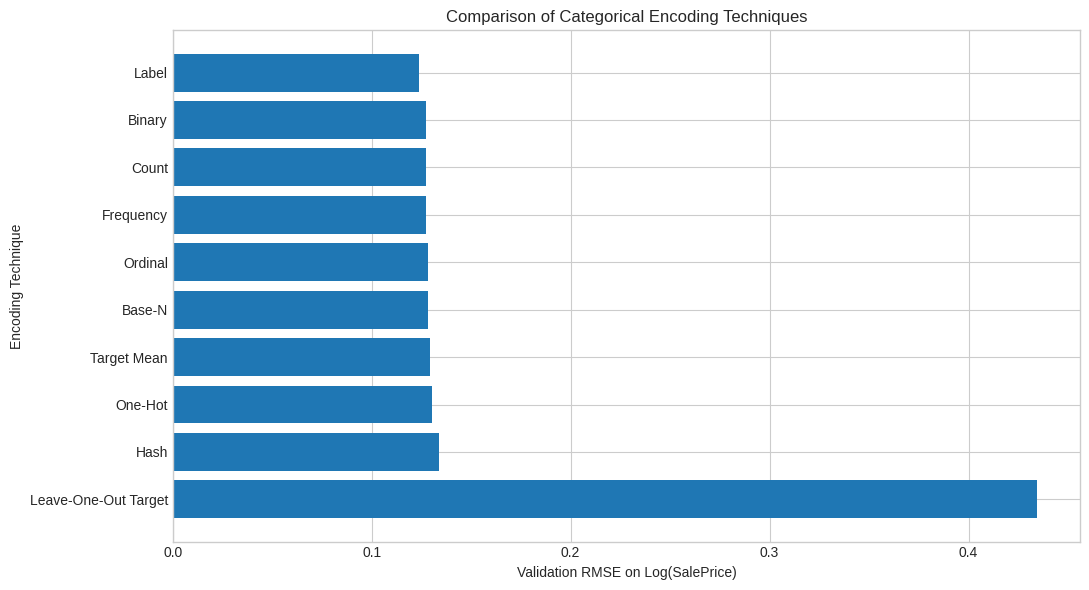

In [25]:
plt.figure(figsize=(11, 6))
plt.barh(
    encoding_results['Encoding'],
    encoding_results['Validation_RMSE_Log']
)
plt.gca().invert_yaxis()
plt.xlabel('Validation RMSE on Log(SalePrice)')
plt.ylabel('Encoding Technique')
plt.title('Comparison of Categorical Encoding Techniques')
plt.tight_layout()
plt.show()

## 8.16 Interpreting the Encoding Experiment

Do not look only at the smallest RMSE.

For each encoding, consider three dimensions:

### Predictive representation

Does the encoding provide useful information to XGBoost?

### Dimensionality

Does the technique create hundreds or thousands of columns, or does it keep the representation compact?

### Information leakage

Does the technique use `SalePrice`? If it does, the calculation must be restricted to the training partition.

This gives us a more complete understanding of encoding than simply saying one method is "best".

## 9. Model Validation Strategy

We set aside 20% of the labeled dataset for validation to evaluate out-of-sample generalization performance prior to scoring test data.


In [26]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set:   {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")


Training set:   1168 samples
Validation set: 292 samples


## 10. XGBoost Model Training & Out-of-Fold Evaluation

We use an XGBoost regressor with controlled tree depth (`max_depth=3`) and conservative learning rate (`learning_rate=0.03`) along with feature/row subsampling to mitigate overfitting on sparse one-hot columns.


In [27]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)

xgb.fit(X_train, y_train)

val_preds = xgb.predict(X_val)
val_rmse = root_mean_squared_error(y_val, val_preds)
print(f"Validation RMSE (Log Scale): {val_rmse:.4f}")


Validation RMSE (Log Scale): 0.1309


## 11. Feature Importance Analysis

Examining the features XGBoost relied on most reveals whether the model learned intuitive housing drivers (e.g. overall quality, square footage, basement finishing).


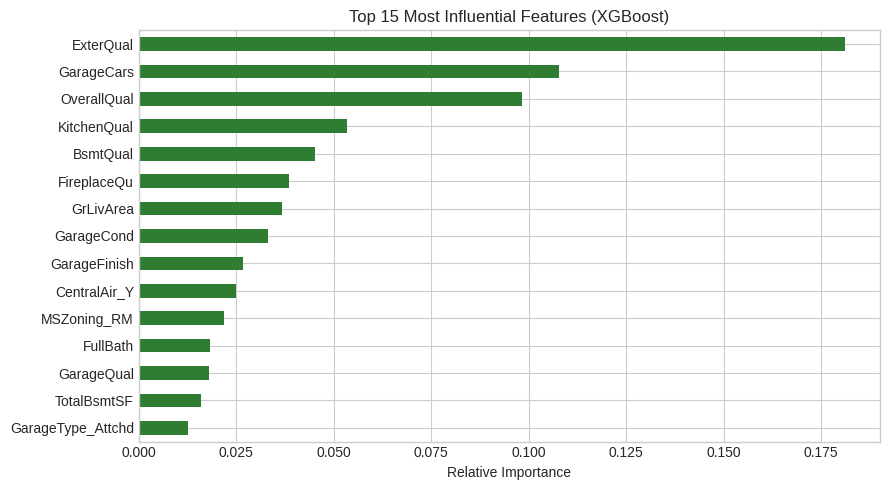

In [33]:
importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind='barh', color='#2e7d32')
plt.title('Top 15 Most Influential Features (XGBoost)', fontsize=12)
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()


## 12. Full-Data Retraining & Submission Generation

To maximize predictive power on Kaggle test instances, we retrain the model across 100% of the available training data (`X, y`) and revert predictions from log-space back into dollar values using `np.expm1`.


In [34]:
xgb_final = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=42
)
xgb_final.fit(X, y)

final_preds = np.expm1(xgb_final.predict(X_test))

submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': final_preds
})

submission.to_csv('submission.csv', index=False)
print("Submission file successfully saved as 'submission.csv'!")
submission.head()


Submission file successfully saved as 'submission.csv'!


,Id,SalePrice
0,1461,121999.164062
1,1462,158199.531250
2,1463,186591.531250
3,1464,187945.968750
4,1465,184186.703125
